 --- Onda LI-A1.txt --- 
NP Opt 2:    Indice=    0, Offset= -50003.00, Tiempo= 0.233 ms


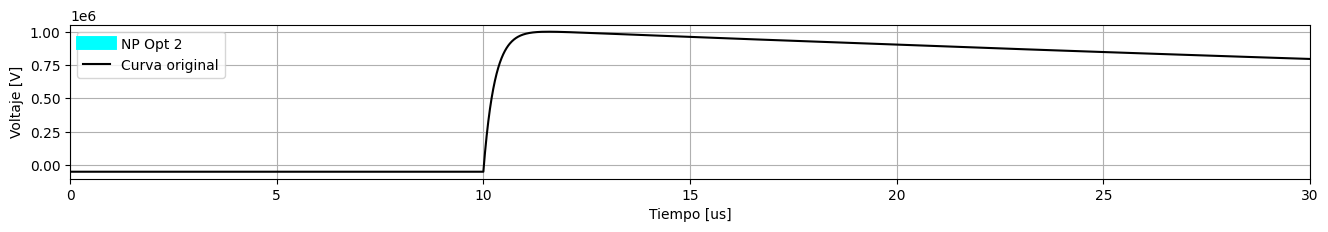

 --- Onda LI-A2.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.306 ms


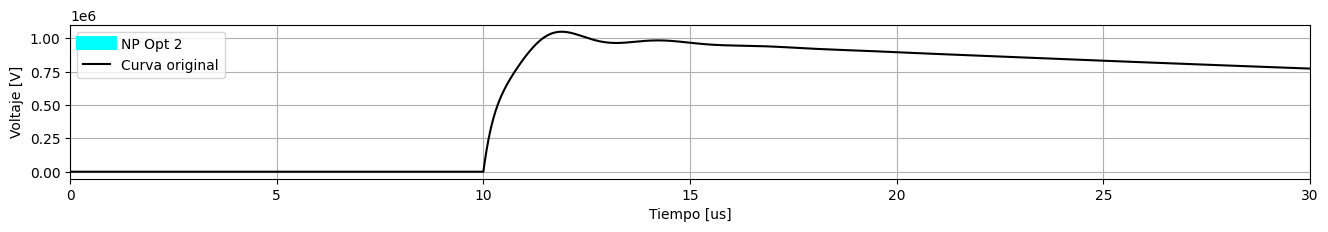

 --- Onda LI-A3.txt --- 
NP Opt 2:    Indice= 1000, Offset= 24999.80, Tiempo= 0.360 ms


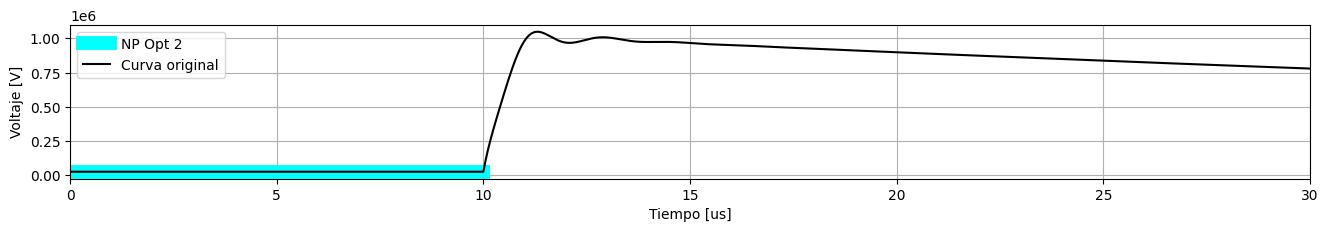

 --- Onda LI-A4.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 1.898 ms


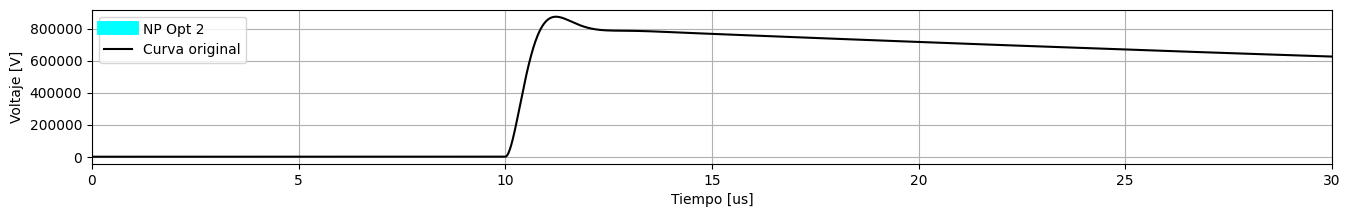

 --- Onda LI-A5.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.264 ms


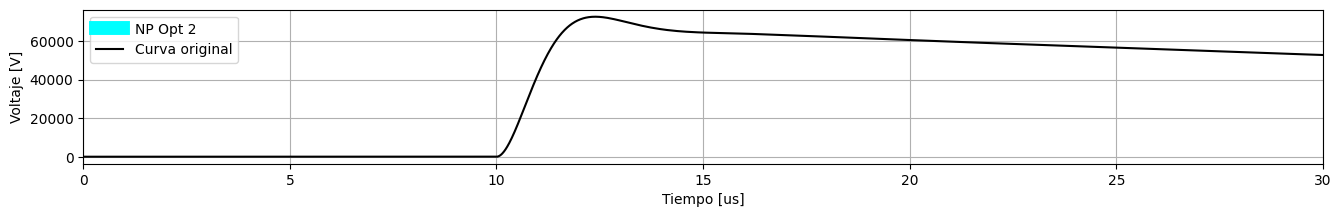

 --- Onda LI-A6.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.936 ms


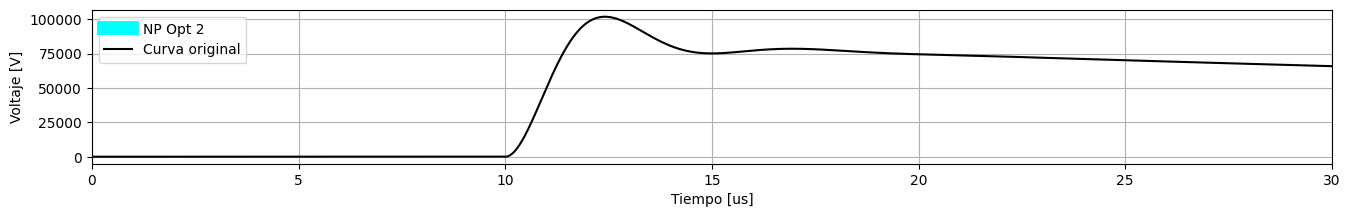

 --- Onda LI-A7.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.518 ms


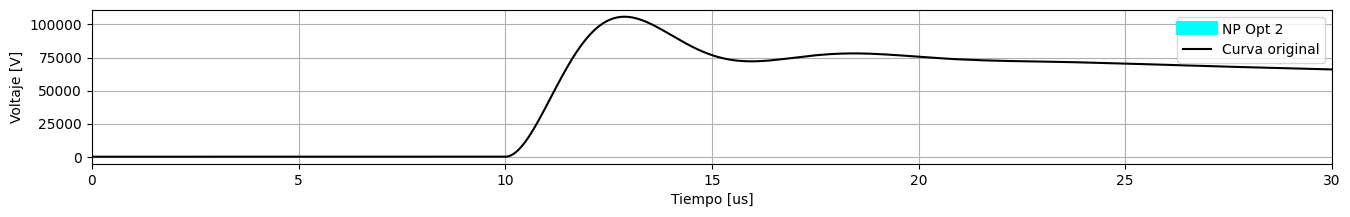

 --- Onda LI-A8.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.294 ms


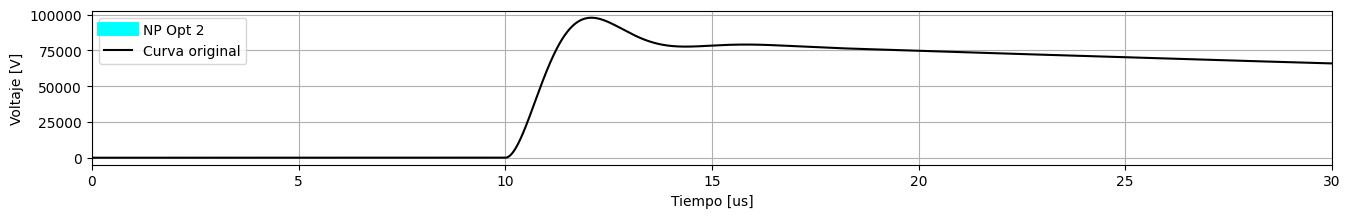

 --- Onda LI-A9.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.443 ms


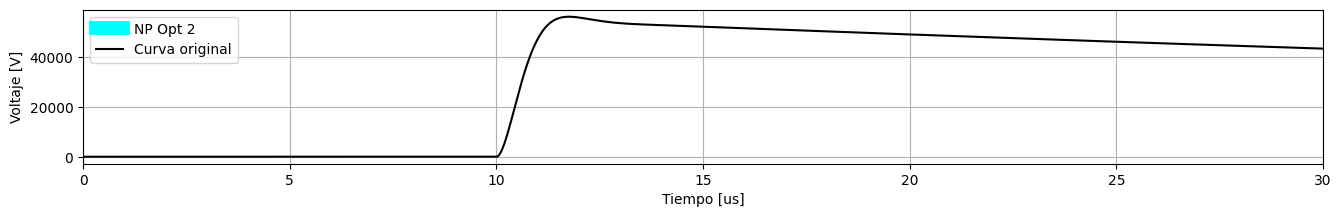

 --- Onda LI-A10.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.302 ms


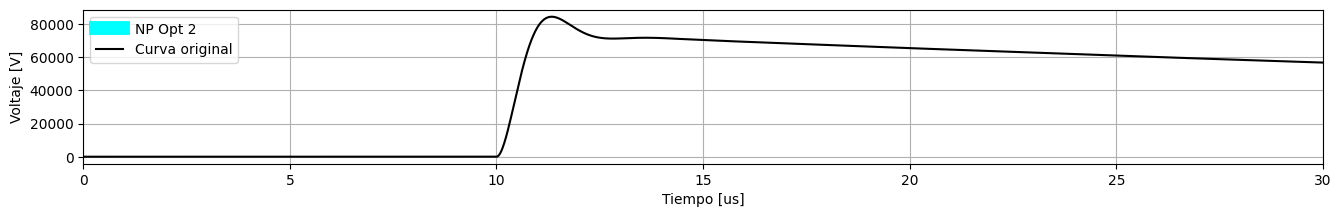

 --- Onda LI-A11.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.218 ms


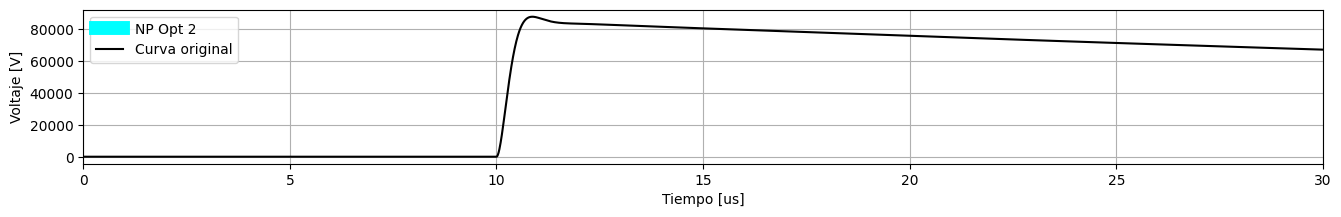

 --- Onda LI-A12.txt --- 
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.297 ms


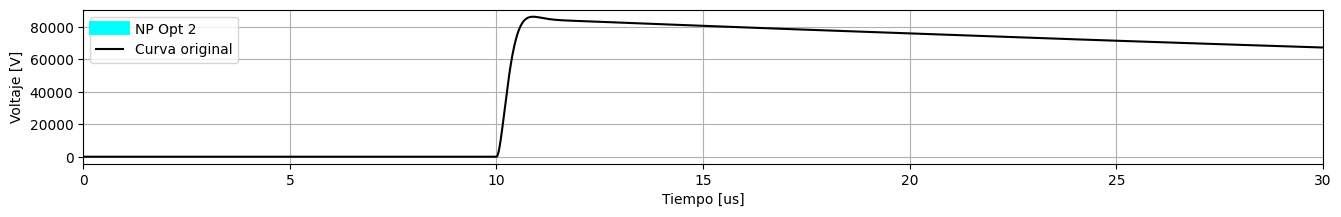

Inicio 30%
NP Opt 2:    Indice=    0, Offset= -50003.00, Tiempo= 0.233 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.306 ms
NP Opt 2:    Indice= 1000, Offset= 24999.80, Tiempo= 0.360 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 1.898 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.264 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.936 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.518 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.294 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.443 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.302 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.218 ms
NP Opt 2:    Indice=    0, Offset= 0.00, Tiempo= 0.297 ms


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from administrar_carpetas import *
#from procesador_de_senales import *
#from report import *
from scipy import signal
import time

def detect_impulse_start(metodo, time_axis, raw_voltage):
    # 1. Calcular derivada suave
    # window_length grande = menos ruido, pero frente más lento. Valores típicos: 21-51.
    dy = signal.savgol_filter(raw_voltage, window_length=11, polyorder=3, deriv=1)
    max_slope = np.max(np.abs(dy))
    idx_max_slope = np.argmax(np.abs(dy))

    idx = 0
    umbral_ratio = 0.005  # % de la máxima derivada.
    threshold = umbral_ratio * max_slope

    if metodo == 'forward':
        # Buscar el primer punto que supere el umbral
        candidatos = np.where(np.abs(dy) > threshold)[0]
        if len(candidatos) > 0:
            idx = candidatos[0]
        else:
            idx = 0
    elif metodo == 'backward':
        # Buscar desde el punto de máxima pendiente hacia atrás.
        for i in range(idx_max_slope, 0, -1):
            if np.abs(dy[i]) < threshold:
                idx = i
                break

    if idx > 0:
        background_noise = raw_voltage[:idx]
        time_axis_2 = time_axis[:idx]
    else:
        background_noise = raw_voltage[0]
        time_axis_2 = time_axis[0]
    offset_value = np.mean(background_noise)
    #print(f"{metodo}: Índice = {idx_inicio}, Offset = {offset_value}")

    return idx, offset_value, time_axis_2, background_noise

def numpy_standard(time_axis, raw_voltage):
    n = int(len(raw_voltage) * 0.01)
    subset = raw_voltage[:n]

    mean = np.mean(subset)
    std = np.std(subset)
    k = 1

    boolean_mask = np.abs(raw_voltage - mean) <= (k * std)

    # Buscar índices donde la máscara es True
    valid_index = np.where(boolean_mask)[0]

    if valid_index.size > 0:
        idx = valid_index[-1]
        background_noise = raw_voltage[:idx]
        time_axis_2 = time_axis[:idx]
    else:
        idx = 0
        background_noise = raw_voltage[0]
        time_axis_2 = time_axis[0]

    offset_value = np.mean(background_noise)
    #print(f"NP: Índice = {m}, Offset = {offset_value}")

    return idx, offset_value, time_axis_2, background_noise

def numpy_opt(time_axis, raw_voltage):
    n = int(raw_voltage.shape[0] * 0.01)
    subset = raw_voltage[:n]

    mean = np.mean(subset)
    std = np.std(subset)
    threshold = 1 * std

    diff = np.abs(raw_voltage - mean)

    # np.flatnonzero devuelve índices que no son cero (False).
    valid_index = np.flatnonzero(diff <= threshold)

    if valid_index.size > 0:
        idx = valid_index[-1]
        background_noise = raw_voltage[:idx]
        time_axis_2 = time_axis[:idx]
    else:
        idx = 0
        background_noise = raw_voltage[0]
        time_axis_2 = time_axis[0]

    offset_value = np.mean(background_noise)
    #print(f"NP Opt: Índice = {m}, Offset = {offset_value}")

    return idx, offset_value, time_axis_2, background_noise

def numpy_opt_2(time_axis, raw_voltage):
    idx_peak = np.argmax(np.abs(raw_voltage))
    front = raw_voltage[:idx_peak]
    n = int(idx_peak * 0.3)
    subset = raw_voltage[:n]

    mean = np.mean(subset)
    std = np.std(subset)

    # np.flatnonzero devuelve índices que no son cero (False).
    diff = np.abs(front - mean)
    max_index = np.flatnonzero(diff >= 5 * std)[0]

    diff_2 = np.abs(front[:max_index] - mean)
    valid_index = np.flatnonzero(diff_2 <= std)

    if valid_index.size > 0:
        idx = valid_index[-1]
        background_noise = raw_voltage[:idx]
        time_axis_2 = time_axis[:idx]
    else:
        idx = 0
        background_noise = raw_voltage[0]
        time_axis_2 = time_axis[0]

    offset_value = np.mean(background_noise)
    #print(f"NP Opt 2: Índice = {idx}, Offset = {offset_value}")

    return idx, offset_value, time_axis_2, background_noise

def plotter(time_1, voltage_1, label_1, time_2, voltage_2, label_2):
    plt.figure(figsize=(16,2))
    plt.plot(time_2*1e6, voltage_2, color='cyan', linewidth=10, label=label_2)
    plt.plot(time_1*1e6, voltage_1, color='black', label=label_1)
    plt.xlim(0, 30)
    y = 10000
    #plt.ylim(-y, y)
    #plt.yticks(np.arange(-360, 1, 45)) # Paso de la grilla
    plt.xlabel("Tiempo [us]")
    plt.ylabel("Voltaje [V]")
    plt.legend()
    plt.grid(True)
    plt.show()
    return

if __name__ == "__main__":
    gestor = FileManager()
    LAT =   ['1', '2', '3', '4', '5', '6', '7', '8']
    IEC_1 = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
    IEC_2 = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17']
    IEC_3 = ['A1', 'M1', 'M2', 'M3', 'M4c', 'M4f', 'M5c', 'M5f']

    bandera = 1
    match bandera:
        case 0:
            conjunto = LAT
        case 1:
            conjunto = IEC_1
        case 2:
            conjunto = IEC_2
        case 3:
            conjunto = IEC_3

    resumen = ["Inicio 30%"]
    for n in conjunto:
        match bandera:
            case 0:
                file = "LAT_" + n + ".txt"
                calibration_file = Path.cwd().parent.parent / "Calibracion" / "LAT" / file
            case 1:
                file = "LI-A" + n + ".txt"
                calibration_file = Path.cwd().parent.parent / "Calibracion" / "IEC61083_2" / file
            case 2:
                file = "LI-M" + n + ".txt"
                calibration_file = Path.cwd().parent.parent / "Calibracion" / "IEC61083_2" / file
            case 3:
                file = "LIC-" + n + ".txt"
                calibration_file = Path.cwd().parent.parent / "Calibracion" / "IEC61083_2" / file

        metadata, voltage_data = gestor.read_calibration_file(calibration_file)
        raw_voltage = np.array(voltage_data)
        time_axis = np.arange(len(raw_voltage)) * metadata['rate']

        print(f" --- Onda {file} --- ")
        t0 = time.time()
        idx_1, offset_1, time_axis_1, voltage_1 = detect_impulse_start('forward', time_axis, raw_voltage)
        t1 = time.time()
        idx_2, offset_2, time_axis_2, voltage_2 = detect_impulse_start('backward', time_axis, raw_voltage)
        t2 = time.time()
        idx_3, offset_3, time_axis_3, voltage_3 = numpy_standard(time_axis, raw_voltage)
        t3 = time.time()
        idx_4, offset_4, time_axis_4, voltage_4 = numpy_opt(time_axis, raw_voltage)
        t4 = time.time()
        idx_5, offset_5, time_axis_5, voltage_5 = numpy_opt_2(time_axis, raw_voltage)
        t5 = time.time()

        #print(f"Forward:     Indice= {idx_1:4d}, Offset= {offset_1:.2f}, Tiempo= {(t1 - t0)*1e3:.3f} ms")
        #print(f"Backward:    Indice= {idx_2:4d}, Offset= {offset_2:.2f}, Tiempo= {(t2 - t1)*1e3:.3f} ms")
        #print(f"NP Standard: Indice= {idx_3:4d}, Offset= {offset_3:.2f}, Tiempo= {(t3 - t2)*1e3:.3f} ms")
        #print(f"NP Opt:      Indice= {idx_4:4d}, Offset= {offset_4:.2f}, Tiempo= {(t4 - t3)*1e3:.3f} ms")
        print(f"NP Opt 2:    Indice= {idx_5:4d}, Offset= {offset_5:.2f}, Tiempo= {(t5 - t4)*1e3:.3f} ms")
        #plotter(time_axis, raw_voltage, 'Curva original', time_axis_1, voltage_1, 'Forward')
        #plotter(time_axis, raw_voltage, 'Curva original', time_axis_2, voltage_2, 'Backward')
        #plotter(time_axis, raw_voltage, 'Curva original', time_axis_3, voltage_3, 'NP Standard')
        #plotter(time_axis, raw_voltage, 'Curva original', time_axis_4, voltage_4, 'NP Opt')
        plotter(time_axis, raw_voltage, 'Curva original', time_axis_5, voltage_5, 'NP Opt 2')
        resumen.append(f"NP Opt 2:    Indice= {idx_5:4d}, Offset= {offset_5:.2f}, Tiempo= {(t5 - t4)*1e3:.3f} ms")

    for i in resumen:
        print(i)